# Durables vs Non Durables At Low And High Frequencies

The data are **real** personal consumption expenditures on durable and nondurable goods: BEA's chain-type quantity indexes, [DDURRA3Q086SBEA](https://fred.stlouisfed.org/series/DDURRA3Q086SBEA) and [DNDGRA3Q086SBEA](https://fred.stlouisfed.org/series/DNDGRA3Q086SBEA) on FRED. The growth rate of a quantity index is a real growth rate, so no separate deflation is needed.

An earlier version of this notebook used *nominal* spending (`PCDG` and `PCND`). Inflation raises both nominal series together, so much of their apparent co-movement, particularly in the 1970s, came from common inflation rather than from the relationship between real spending on durables and nondurables that the theory is about.

In [1]:
# Some initial setup
from matplotlib import pyplot as plt
import numpy as np
#plt.style.use('seaborn-darkgrid')
plt.style.use('seaborn-v0_8-darkgrid')
import pandas as pd
import datetime
import seaborn as sns

In [2]:
# Import Quarterly data from FRED, reading each series' CSV download directly
def fred(series, start, end):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"
    return pd.read_csv(url, index_col=0, parse_dates=True).loc[start:end]


start = datetime.datetime(1947, 1, 1) #beginning of series
start1 = datetime.datetime(1956, 10, 1) #beginning of series

end = datetime.datetime(2018, 4, 1) #end of series

# Real spending: BEA's chain-type quantity indexes, so growth rates are free of inflation
DUR  = 'DDURRA3Q086SBEA' # Real PCE: durable goods
NDUR = 'DNDGRA3Q086SBEA' # Real PCE: nondurable goods

PCDG = fred(DUR, start, end).set_axis(['Durables'], axis=1) #loads your durable goods quarterly series data
PCND = fred(NDUR, start, end).set_axis(['Nondurables'], axis=1) #Loads your non durable goods quarterly series data
PCDG1 = fred(DUR, start1, end).set_axis(['Durables'], axis=1) #loads your durable goods quarterly series data, helps in having time series of identical length
PCND1 = fred(NDUR, start1, end).set_axis(['Nondurables'], axis=1) #Loads your non durable goods quarterly series data, , helps in having time series of identical length

In [3]:
# Constructing PCDG and PCND growth series () 
z1=PCDG.pct_change(periods=40)# 10*4
z2=PCND.pct_change(periods=40)#10*4
z3=PCDG1.pct_change(periods=1)# 
z4=PCND1.pct_change(periods=1)#
s1=z1*100 #(In percentage terms)
s2=z2*100 #(In percentage terms)
s3=z3*100 #(In percentage terms)
s4=z4*100 #(In percentage terms)

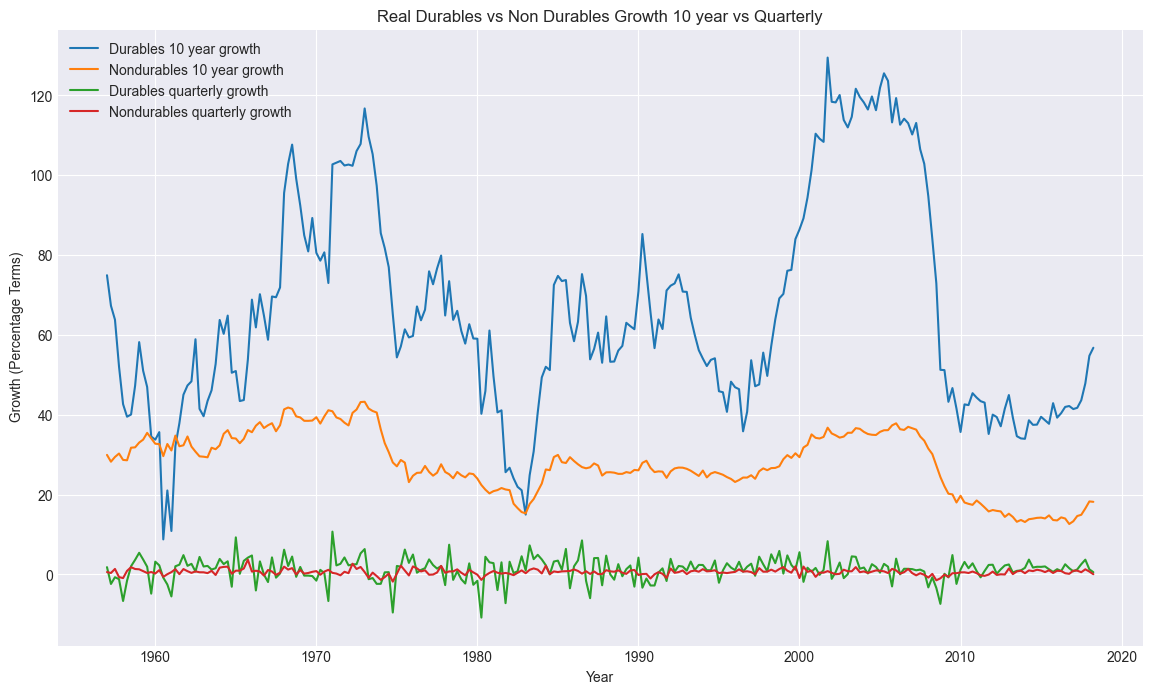

In [4]:
# Plotting the growth rates
plt.figure(figsize=((14,8))) # set the plot size
plt.title('Real Durables vs Non Durables Growth 10 year vs Quarterly')
plt.xlabel('Year')
plt.ylabel(' Growth (Percentage Terms)')
plt.plot(s1,label="Durables 10 year growth")
plt.plot(s2,label="Nondurables 10 year growth")
plt.plot(s3,label="Durables quarterly growth")
plt.plot(s4,label="Nondurables quarterly growth")
plt.legend()
plt.show()

In [5]:
# Drops the missing NAN observations

a1=s1.dropna()#Drops the missing values from s1 series
a2=s2.dropna()#Drops the missing values from s2 series
a3=s3.dropna()#Drops the missing values from s3 series
a4=s4.dropna()#Drops the missing values from s4 series

In [6]:
# concatate (merge) the two series
c1=pd.concat([a1, a2], axis=1)
c2=pd.concat([a3, a4], axis=1)

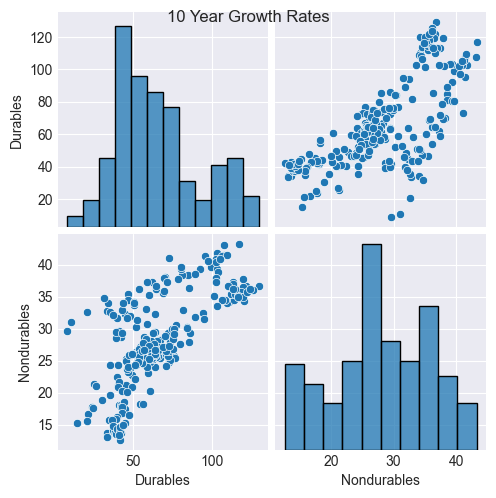

In [7]:
#Pairwise Plotting for the 10 year growth series

sns.pairplot(c1)
plt.suptitle('10 Year Growth Rates')
plt.show()

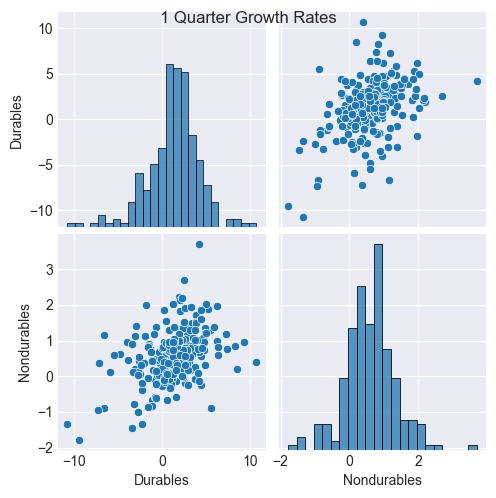

In [8]:
#Pairwise Plotting for the quarterly growth series

sns.pairplot(c2)
plt.suptitle('1 Quarter Growth Rates')
plt.show()

For each frequency [quarterly|10-year] each moment of time would correspond to a single point (x=nondurables growth, y=durables growth).  At both frequencies real spending on durables is far more variable than real spending on nondurables, and the more so at the 1 quarter frequency.

Over the long run, real spending on durables has also grown much faster than real spending on nondurables, because durable goods have become steadily cheaper relative to nondurables.